In [1]:
name = 'fake_cube_mod_finite_sigE0_m300_r8_N128'

In [2]:
import time
start_time=time.time()

In [3]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
import astropy.units as u
from matplotlib import pyplot as plt
import corner
import json
from astropy.io import fits
from lmfit.model import load_modelresult

# Add path to py_modules 
sys.path.append(str(Path().resolve() / 'py_modules')) # 1 level up = project root

#from turb_utils import make_extended, make_3dfield
#import strucfunc                   
import ci_results_compiler
import fit_structure_function
import bfunc
import bplot

In [4]:
hdul = fits.open('fake_maps_data/' + name + '.fits')
hdr = hdul[0].header
print(hdul.info())
print(hdr)
sb = hdul['MOM0'].data.astype(float)
vv= hdul['MOM1'].data.astype(float)

Filename: fake_maps_data/fake_cube_mod_finite_sigE0_m300_r8_N128.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      18   ()      
  1  MOM0          1 ImageHDU         8   (128, 128)   float64   
  2  MOM1          1 ImageHDU         8   (128, 128)   float64   
None
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  AUTHOR  = 'J. Garcia-Vazquez'  / File creator                                   M3D     =                  0.0 / k = 3 + m3D                                    RA      =                  8.0 / Artificial correlation length                  SIG     =   0.1224503663603722 / Standard deviation vel artificial map          SIG2    =  0.01499409222178937 / Vel Var

# Loading and Plotting velocity field

In [5]:
hdul = fits.open('fake_maps_data/' + name + '.fits')

m3D      = hdul[0].header['M3D']
ra       = hdul[0].header['RA']
sig      = hdul[0].header['SIG']
sig2     = hdul[0].header['SIG2']
s0       = hdul[0].header['S0']
noise    = hdul[0].header['NOISE']
box_size = hdul[0].header['BOX_SIZE']
pc       = hdul[0].header['PC']
pix      = hdul[0].header['PIX']
line     = hdul[0].header['LINE']
binsize  = hdul[0].header['BINSIZE']


<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ZAINTEL2\AppData\Local\Temp\ipykernel_18168\704268605.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


Text(0.5, 0, 'pix')

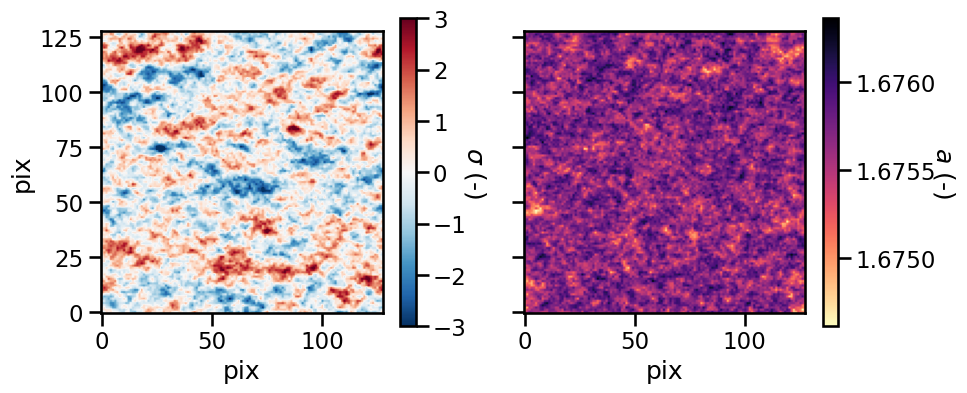

In [6]:
fig, (ax, axx) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", vmin=-3, vmax=3, cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma_r")
im = ax.imshow(vv, **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(sb, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)

ax.set_xlabel("pix")
ax.set_ylabel("pix")
axx.set_xlabel("pix")
#ax.set_title("3D Tapered")
#axx.set_title("3D Non Tapered")

# Plotting structure function

In [7]:
# Unpacking B(r) results

Br_init = json.load(open( "results_Br/" + name + ".json"))
Br      = Br_init['strucfun_numba_parallel']
#Br

In [8]:
B  = Br['Unweighted B(r)']
Bw = Br['Unweighted B(r)']
r  = 10**np.array(Br['log10 r'])

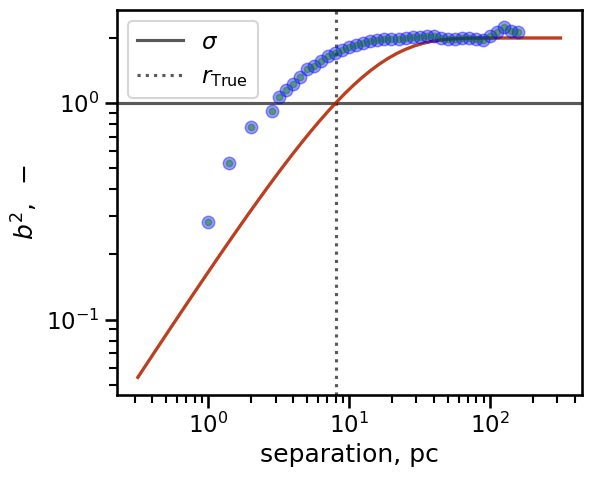

In [9]:
m_obs    = 1.0
sig2norm = 1.0

fig, ax = plt.subplots(figsize=(6, 5))
rgrid = np.logspace(-0.5, 2.5)
ax.errorbar(r, B, fmt='o', alpha=0.4,color="blue")
ax.errorbar(r, Bw, fmt='.', alpha=0.4,color="green")
#ax.errorbar(s, b2w, yerr=e_b2w, xerr=e_s, fmt='x', alpha=0.4,color="green")

ax.axhline(sig2norm, ls='-', label = r'$\sigma$', color="black", alpha = 0.65)
ax.axvline(ra, ls=':', label = r'$r_\text{True}$', color="black", alpha = 0.65)

ax.plot(rgrid, bfunc.bfunc00s(rgrid, ra, sig2norm, m_obs ), color="green", alpha = 0.65)
ax.plot(rgrid, bfunc.bfunc03s(rgrid, ra, sig2norm, m_obs , s0, noise), color="red", alpha = 0.65)

ax.set(xscale='log', yscale='log', 
       xlabel='separation, pc',
#       ylabel=r'$b^2,\ \mathrm{km^2\ s^{-2}}$'
       ylabel=r'$b^2,\ -$'
      )

ax.legend()


None

# Loading Fit and confidence intervals

In [10]:
result = load_modelresult("results_fit/" + name +"result_ideal.sav")
result_emcee = load_modelresult("results_fit/" + name +"result_emcee_ideal.sav")

fit_Br = {
    'result' : result,
    'result_emcee' : result_emcee }

In [11]:
params_Br = ci_results_compiler.ci_results_compiler_ideal(fit_Br)
params_Br

{'sig2': [0.9878972286356484, 0.03533484261685138, 0.03403828759064842],
 'r0': [3.0340185254824554, 0.2509615822225446, 0.2157720035124555],
 'm': [1.2257752003686573, 0.10686322530884262, 0.09782475186115747]}

# Plotting Fit results and confidence intervals

In [12]:
params_Br

{'sig2': [0.9878972286356484, 0.03533484261685138, 0.03403828759064842],
 'r0': [3.0340185254824554, 0.2509615822225446, 0.2157720035124555],
 'm': [1.2257752003686573, 0.10686322530884262, 0.09782475186115747]}

In [13]:
params_Br['sig2'][1]

0.03533484261685138

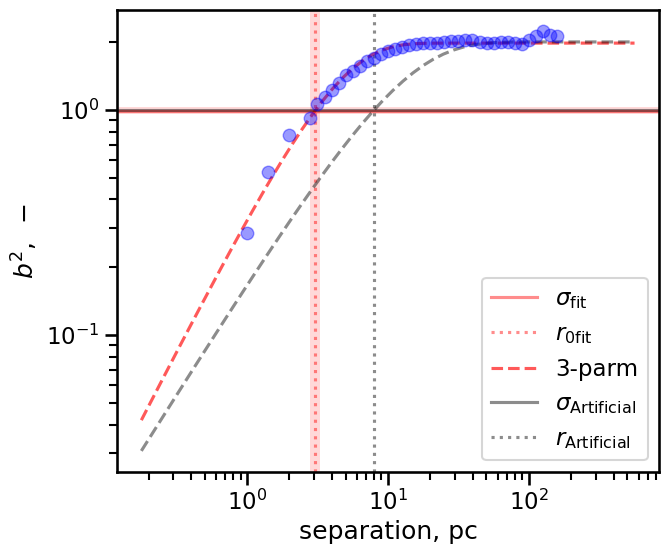

In [24]:
rgrid = np.logspace(-0.75, 2.75)


fig, ax = plt.subplots(figsize=(7, 6))
ax.errorbar(10**np.array(Br['log10 r']), Br['Unweighted B(r)'], fmt='o', alpha=0.4,color="blue")

# Sigma**2
ax.axhspan(params_Br['sig2'][0]-params_Br['sig2'][2],params_Br['sig2'][0]+ params_Br['sig2'][1], facecolor='red', alpha=0.15)
ax.axhline(params_Br['sig2'][0], ls='-', color="red", alpha = 0.45, label = r'$\sigma_\text{fit}$',)

# r0**2
ax.axvspan(params_Br['r0'][0]-params_Br['r0'][2],params_Br['r0'][0]+ params_Br['r0'][1], facecolor='red', alpha=0.15)
ax.axvline(params_Br['r0'][0], ls=':', color="red", alpha = 0.45, label = r'$r_{0\text{fit}}$',)

# S0
#ax.axvspan(params_Br['s0'][0]-params_Br['s0'][2],params_Br['s0'][0]+ params_Br['s0'][1], facecolor='red', alpha=0.15)
#ax.axvline(params_Br['s0'][0], ls='-', color="red", alpha = 0.45)

# Noise
#ax.axhspan(params_Br['noise'][0]-params_Br['noise'][2],params_Br['noise'][0]+ params_Br['noise'][1], facecolor='red', alpha=0.3)
#ax.axhline(params_Br['noise'][0], ls='-', color="red", alpha = 0.65)

ax.plot(rgrid, bfunc.bfunc00s(rgrid, params_Br['r0'][0], params_Br['sig2'][0], params_Br['m'][0]), color="red", alpha = 0.65, ls='--', label = '3-parm')
#ax.plot(rgrid, bfunc.bfunc03s(rgrid, params_Br['r0'][0], params_Br['sig2'][0], params_Br['m'][0], params_Br['s0'][0], params_Br['noise'][0]), 
#        color="green", alpha = 0.65, ls=':', label = '5-parm')

# Ideal
ax.axhline(sig2norm, ls='-', label = r'$\sigma_\text{Artificial}$', color="black", alpha = 0.45)
ax.axvline(ra, ls=':', label = r'$r_\text{Artificial}$', color="black", alpha = 0.45)

ax.plot(rgrid, bfunc.bfunc00s(rgrid, ra, sig2norm, m_obs ), color="black", alpha = 0.45, ls='--')
#ax.plot(rgrid, bfunc.bfunc03s(rgrid, ra, sig2norm, m_obs , s0, noise), color="green", alpha = 0.45, ls=':')

ax.set(xscale='log', yscale='log', 
       xlabel='separation, pc',
#       ylabel=r'$b^2,\ \mathrm{km^2\ s^{-2}}$'
       ylabel=r'$b^2,\ -$'
      )

ax.legend()


None

In [ ]:
print("--- %s seconds ---" % (time.time()-start_time))